# quimb exploration

Testing MPS/TT basics for the TN-LBM implementation.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import quimb as qu
import quimb.tensor as qtn

print(f"quimb version: {qu.__version__}")

quimb version: 1.11.2


## MPS/TT basics

A tensor train with L cores:

$$\mathcal{T}_{q_1 q_2 \ldots q_L} = \sum_{\alpha} A^{(1)}_{q_1,\alpha_1} A^{(2)}_{\alpha_1,q_2,\alpha_2} \ldots A^{(L)}_{\alpha_{L-1},q_L}$$

In [71]:
# random TT with 8 cores
L = 8  # number of cores
d = 2  # physical dimension per core
chi = 4  # bond dimension

psi = qtn.MPS_rand_state(L=L, bond_dim=chi, phys_dim=d)

print(f"cores: {psi.L}")
print(f"phys dim: {psi.phys_dim()}")
print(f"max bond: {psi.max_bond()}")
print(f"total params: {sum(t.size for t in psi)}")
print(f"full tensor: {d**L}")

cores: 8
phys dim: 2
max bond: 4
total params: 208
full tensor: 256


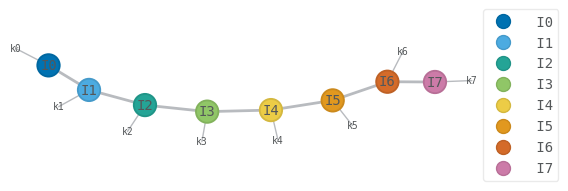

In [72]:
psi.draw(color=['I0', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7'])

In [73]:
# individual core shapes
for i, t in enumerate(psi):
    print(f"core {i}: {t.shape}")

core 0: (4, 2)
core 1: (4, 4, 2)
core 2: (4, 4, 2)
core 3: (4, 4, 2)
core 4: (4, 4, 2)
core 5: (4, 4, 2)
core 6: (4, 4, 2)
core 7: (4, 2)


## QTT encoding

Encode a 1D field with N=2^L points using dyadic decomposition.

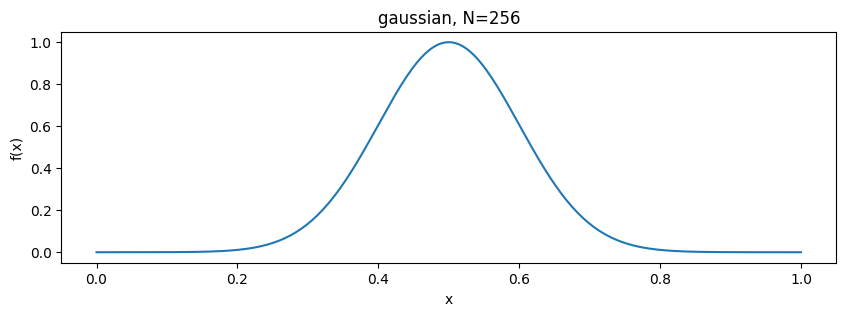

shape: (256,), norm: 6.7229


In [74]:
# gaussian test field
L = 8
N = 2**L
x = np.linspace(0, 1, N)
sigma = 0.1
field = np.exp(-((x - 0.5)**2) / (2 * sigma**2))

plt.figure(figsize=(10, 3))
plt.plot(x, field)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(f'gaussian, N={N}')
plt.show()

print(f"shape: {field.shape}, norm: {np.linalg.norm(field):.4f}")

In [75]:
# reshape for QTT: (N,) -> (2,2,...,2)
field_tensor = field.reshape([2] * L)
print(f"tensor shape: {field_tensor.shape}")

tensor shape: (2, 2, 2, 2, 2, 2, 2, 2)


In [76]:
# convert to MPS via SVD
mps = qtn.MatrixProductState.from_dense(field_tensor, dims=[2]*L)

print(f"cores: {mps.L}")
print(f"max bond: {mps.max_bond()}")
print(f"bond dims: {[mps.bond_size(i, i+1) for i in range(L-1)]}")

cores: 8
max bond: 6
bond dims: [2, 4, 6, 5, 4, 3, 2]


reconstruction error: 6.30e-06


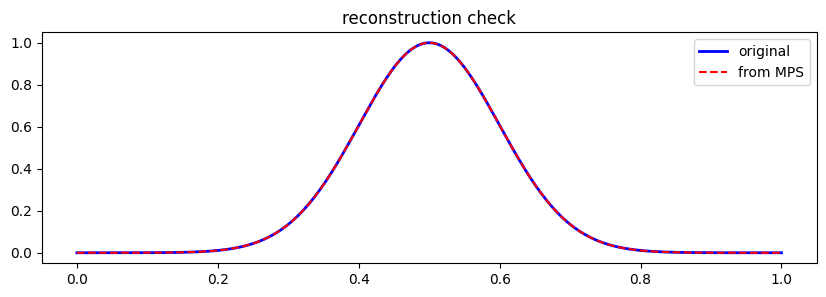

In [77]:
# reconstruction test
reconstructed = mps.to_dense().flatten()
error = np.linalg.norm(field - reconstructed) / np.linalg.norm(field)
print(f"reconstruction error: {error:.2e}")

plt.figure(figsize=(10, 3))
plt.plot(x, field, 'b-', label='original', lw=2)
plt.plot(x, reconstructed, 'r--', label='from MPS')
plt.legend()
plt.title('reconstruction check')
plt.show()

## compression

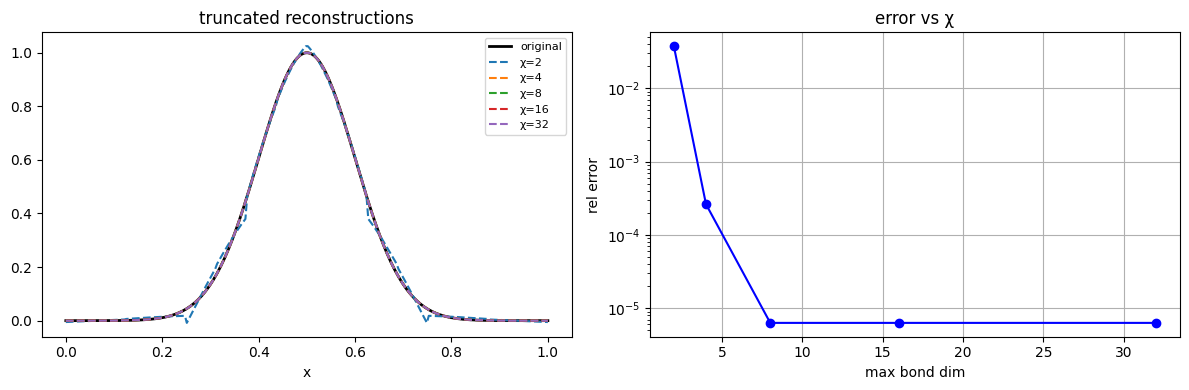

In [78]:
# truncation vs accuracy
chi_values = [2, 4, 8, 16, 32]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(x, field, 'k-', label='original', lw=2)

errors = []
for chi_max in chi_values:
    mps_trunc = qtn.MatrixProductState.from_dense(field_tensor, dims=[2]*L, max_bond=chi_max)
    recon = mps_trunc.to_dense().flatten()
    err = np.linalg.norm(field - recon) / np.linalg.norm(field)
    errors.append(err)
    plt.plot(x, recon, '--', label=f'χ={chi_max}')

plt.xlabel('x')
plt.legend(fontsize=8)
plt.title('truncated reconstructions')

plt.subplot(1, 2, 2)
plt.semilogy(chi_values, errors, 'bo-')
plt.xlabel('max bond dim')
plt.ylabel('rel error')
plt.grid(True)
plt.title('error vs χ')

plt.tight_layout()
plt.show()

## arithmetic

Need for LBM: addition, scalar mult, element-wise product.

In [79]:
# two gaussians (overlapping)
field1 = np.exp(-((x - 0.4)**2) / (2 * 0.1**2))
field2 = np.exp(-((x - 0.6)**2) / (2 * 0.1**2))

mps1 = qtn.MatrixProductState.from_dense(field1.reshape([2]*L), dims=[2]*L)
mps2 = qtn.MatrixProductState.from_dense(field2.reshape([2]*L), dims=[2]*L)

print(f"mps1 bond: {mps1.max_bond()}")
print(f"mps2 bond: {mps2.max_bond()}")

mps1 bond: 6
mps2 bond: 6


sum bond: 12 (was 6+6)
error: 5.19e-06


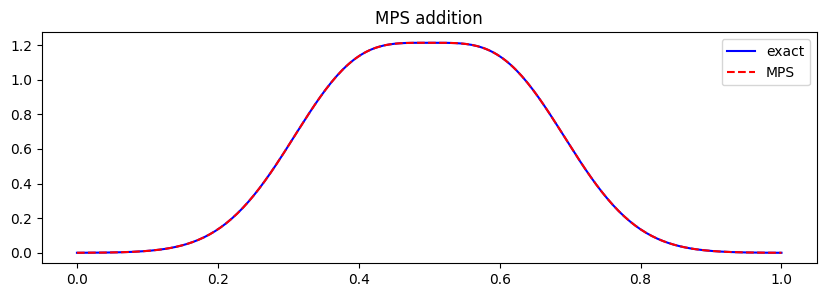

In [80]:
# addition (bond dims add)
mps_sum = mps1.add_MPS(mps2)
print(f"sum bond: {mps_sum.max_bond()} (was {mps1.max_bond()}+{mps2.max_bond()})")

sum_recon = mps_sum.to_dense().flatten()
sum_exact = field1 + field2
print(f"error: {np.linalg.norm(sum_recon - sum_exact) / np.linalg.norm(sum_exact):.2e}")

plt.figure(figsize=(10, 3))
plt.plot(x, sum_exact, 'b-', label='exact')
plt.plot(x, sum_recon, 'r--', label='MPS')
plt.legend()
plt.title('MPS addition')
plt.show()

In [81]:
# compress after addition
mps_compressed = mps_sum.copy()
mps_compressed.compress(max_bond=16)
print(f"compressed bond: {mps_compressed.max_bond()}")

compressed_recon = mps_compressed.to_dense().flatten()
print(f"compression error: {np.linalg.norm(compressed_recon - sum_exact) / np.linalg.norm(sum_exact):.2e}")

compressed bond: 6
compression error: 7.07e-06


In [82]:
# scalar mult
alpha = 2.5
mps_scaled = mps1.multiply(alpha, inplace=False)

scaled_recon = mps_scaled.to_dense().flatten()
print(f"scalar mult error: {np.linalg.norm(scaled_recon - alpha*field1) / np.linalg.norm(alpha*field1):.2e}")

scalar mult error: 6.33e-06


## hadamard product

Critical for collision - naive approach squares bond dim. Will need TTM or HaTT later.

hadamard bond: 6


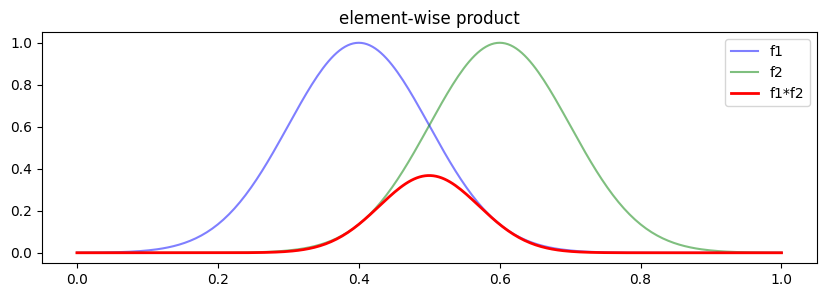

In [83]:
# for now just compute dense and re-encode
hadamard_exact = field1 * field2

mps_hadamard = qtn.MatrixProductState.from_dense(hadamard_exact.reshape([2]*L), dims=[2]*L)
print(f"hadamard bond: {mps_hadamard.max_bond()}")

plt.figure(figsize=(10, 3))
plt.plot(x, field1, 'b-', alpha=0.5, label='f1')
plt.plot(x, field2, 'g-', alpha=0.5, label='f2')
plt.plot(x, hadamard_exact, 'r-', lw=2, label='f1*f2')
plt.legend()
plt.title('element-wise product')
plt.show()

## MPO basics

For streaming - operators that act on MPS.

In [84]:
# identity MPO
mpo_id = qtn.MPO_identity(L=L, phys_dim=2)

print(f"MPO cores: {mpo_id.L}")
print(f"MPO bond: {mpo_id.max_bond()}")

result = mpo_id.apply(mps1)
result_dense = result.to_dense().flatten()
print(f"identity error: {np.linalg.norm(result_dense - field1):.2e}")

MPO cores: 8
MPO bond: 1
identity error: 4.25e-05


## memory scaling

In [85]:
L_vals = [6, 8, 10, 12, 14, 16]
chi = 8

print(f"{'L':>3} {'N':>8} {'full':>10} {'MPS':>10} {'ratio':>8}")
print("-" * 42)

for L in L_vals:
    N = 2**L
    full_kb = N * 8 / 1024
    mps_kb = L * chi**2 * 2 * 8 / 1024
    ratio = full_kb / mps_kb
    print(f"{L:>3} {N:>8} {full_kb:>9.2f}K {mps_kb:>9.2f}K {ratio:>7.1f}x")

  L        N       full        MPS    ratio
------------------------------------------
  6       64      0.50K      6.00K     0.1x
  8      256      2.00K      8.00K     0.2x
 10     1024      8.00K     10.00K     0.8x
 12     4096     32.00K     12.00K     2.7x
 14    16384    128.00K     14.00K     9.1x
 16    65536    512.00K     16.00K    32.0x
